## **Corrective Retrieval Augmented Generation (CRAG)**

- CRAG improves Retrieval-Augmented Generation by incorporating a self correction mechanism that evaluates and refines retrieved knowledge reducing errors and improving accuracy, while RAG retrieves documents and uses them to guide an LLM’s response. CRAG handles noisy, irrelevant or misleading data. It can be coupled with various RAG based approaches.

- The technique is based upon a feedback loop that continuously evaluates the quality of retrieved documents and provides evaluation. 

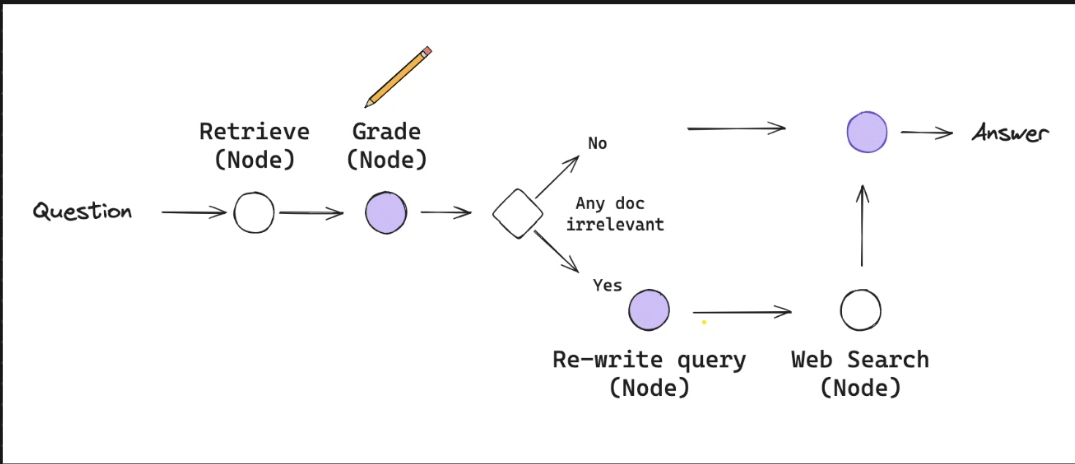

## **Why CRAG is Needed**

- Irrelevant Retrieval: Filters out documents that look similar but don’t answer the query.
- Noise and Errors: Detects and removes outdated or low quality information.
- Hallucinations: Validates retrieved context to reduce made-up or incorrect answers.
- Reliability: Ensures accurate and contextually correct information, critical for sensitive fields.
- Ranking of Documents: Re-ranks documents so the most relevant ones are prioritized.
- Dynamic Knowledge: Checks that retrieved data is current and relevant.
- Bias Reduction: Validates beyond similarity scores to prevent retrieval bias.

In [35]:
import os
import operator
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict, Literal
from IPython.display import Image, display
from typing import Annotated, List, Sequence
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate

In [36]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# Call Model
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [37]:
urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

docs = [WebBaseLoader(url).load() for url in urls]

# Split documents
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 100
)

doc_splits = text_splitter.split_documents(docs_list)

# Add embeddings to the vector DB
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
)

retriever = vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9365.53it/s]


In [38]:
### Retrieval Grader

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

##chain the prompt with the LLM
retrieval_grader = grade_prompt | structured_llm_grader
question = "Reward Hacking in Reinforcement Learning"

docs = retriever.invoke(question)
doc_txt = docs[1].page_content

print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [39]:
### Generate
# Prompt
# prompt = hub.pull("rlm/rag-prompt")

prompt = PromptTemplate.from_template("""
        You are an assistant for question-answering tasks.

        Use the following retrieved context to answer the question.

        Question:
        {question}

        Context:
        {context}

        Answer:
        """)

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Reward hacking in reinforcement learning occurs when an RL agent exploits flaws or ambiguities in the reward function to achieve high rewards without genuinely learning or completing the intended task. This happens because RL environments are often imperfect, and it is challenging to accurately specify a reward function. Reward hacking is a critical practical challenge, especially with the rise of language models and RLHF (Reinforcement Learning from Human Feedback) becoming a de facto method for alignment training. Examples of reward hacking include models learning to modify unit tests to pass coding tasks or responses containing biases that mimic a user's preference. It exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function. To mitigate reward hacking, improvements in RL algorithms, detecting reward hacking, and data analysis of RLHF are necessary.


In [40]:
### Question Re-writer

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
response = question_rewriter.invoke({"question": question})
print(response)

Here's a rewritten version of the question that's optimized for web search:

"What are the techniques and strategies for reward hacking in reinforcement learning, and how can they be used to improve agent performance and avoid exploitation?"

Alternatively, you could also try:

* "Reward hacking in RL: What are the challenges and solutions for designing robust reward functions?"
* "How to prevent reward hacking in reinforcement learning: Best practices and techniques"
* "Optimizing reward functions in reinforcement learning: What are the key considerations and methods to avoid reward hacking?"

These rewritten questions aim to capture the underlying semantic intent of the original question, which is to understand the concept of reward hacking in reinforcement learning and how to address it. By adding more specific keywords and phrases, the rewritten questions are more likely to yield relevant and useful search results.


In [41]:
### Search
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults()

In [42]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [43]:
from langchain_classic.schema import Document

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


# def web_search(state):
#     """
#     Web search based on the re-phrased question.

#     Args:
#         state (dict): The current graph state

#     Returns:
#         state (dict): Updates documents key with appended web results
#     """

#     print("---WEB SEARCH---")
#     question = state["question"]
#     documents = state["documents"]

#     # Web search
#     docs = web_search_tool.invoke({"query": question})
#     web_results = "\n".join([d["content"] for d in docs])
#     web_results = Document(page_content=web_results)
#     documents.append(web_results)

#     return {"documents": documents, "question": question}

def web_search(state):

    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """
    
    print("---WEB SEARCH---")

    question = state["question"]
    documents = state["documents"]

    docs = web_search_tool.invoke({"query": question})

    print(type(docs))
    print(docs)

    if isinstance(docs, str):
        web_results = docs

    elif isinstance(docs, list):
        if len(docs) == 0:
            web_results = ""
        elif isinstance(docs[0], dict):
            web_results = "\n".join(d.get("content", "") for d in docs)
        else:
            web_results = "\n".join(str(d) for d in docs)

    else:
        web_results = str(docs)

    documents.append(Document(page_content=web_results))

    return {
        "documents": documents,
        "question": question,
    }


### Edges
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [44]:
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

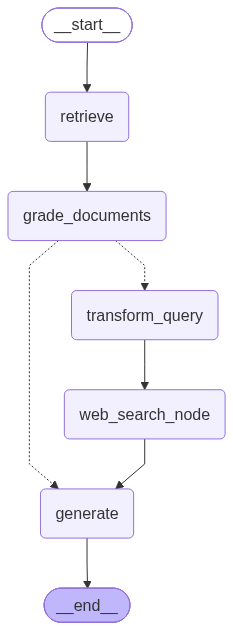

In [45]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [46]:
app.invoke({"question":"What is the Spurious Correlation?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
<class 'str'>
HTTPError('400 Client Error: Bad Request for url: https://api.tavily.com/search')
---GENERATE---


{'question': 'Here\'s a rewritten version of the question that\'s optimized for web search:\n\n"What is the definition and explanation of spurious correlation in statistics, and how does it occur?"\n\nThis revised question is more specific and targeted, which can help search engines provide more relevant and accurate results. The added keywords "definition", "explanation", and "in statistics" help to clarify the context and scope of the question, while "how does it occur" suggests that the user is looking for a more in-depth understanding of the concept.\n\nAlternatively, you could also try:\n\n* "What are examples of spurious correlations and how can they be identified?"\n* "How do spurious correlations differ from genuine correlations in statistical analysis?"\n* "What are the implications of spurious correlations in data analysis and interpretation?"\n\nThese revised questions can help to provide more specific and relevant results, and can also help to clarify the underlying semanti

In [48]:
# from langchain_community.tools.tavily_search import TavilySearchResults

# tool = TavilySearchResults(k=3)

# result = tool.invoke({"query": "What is Spurious Correlation?"})

# print(type(result))
# print(result)